In [1]:
print('Hello')

Hello


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [36]:
df=pd.read_csv("../data/movies.csv")

In [4]:
df.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [5]:
df.shape

(124235, 5)

In [6]:
df.columns

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [8]:
df.isnull().sum()


person_id        0
id               0
name             0
character    16287
role             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(56)

In [11]:
df['role'].value_counts()

role
ACTOR       115846
DIRECTOR      8389
Name: count, dtype: int64

In [14]:
df.head()
df.shape
df.columns
df.info
df.isnull().sum()
df.duplicated().sum()
df['role'].value_counts()

role
ACTOR       115846
DIRECTOR      8389
Name: count, dtype: int64

In [15]:
df_clean=df.copy()

In [16]:
df_clean.isnull().sum()

person_id        0
id               0
name             0
character    16287
role             0
dtype: int64

In [6]:
df_clean = df.copy()

df_clean['character'] = df_clean['character'].fillna('Unknown')

df_clean = df_clean.drop_duplicates()

In [8]:
df_clean['character'] = df_clean['character'].fillna('Unknown')

In [9]:
df_clean.shape

(124179, 5)

In [18]:
df_clean.isnull().sum()

person_id    0
id           0
name         0
character    0
role         0
dtype: int64

In [19]:
df_clean.duplicated().sum()

np.int64(56)

In [20]:
df_clean['role'].value_counts()

role
ACTOR       115846
DIRECTOR      8389
Name: count, dtype: int64

In [21]:
df_clean = df_clean.drop_duplicates()

In [22]:
df_clean.duplicated().sum()

np.int64(0)

In [23]:
df_clean.shape

(124179, 5)

In [24]:
df_clean['role'].value_counts()

role
ACTOR       115793
DIRECTOR      8386
Name: count, dtype: int64

In [25]:
df_clean['person_id'].nunique()

80508

In [26]:
df_clean['id'].nunique()

8861

In [27]:
df_clean['name'].value_counts().head(10)

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Joseph Kane             41
Gene Autry              40
Sam Newfield            38
Nassar                  37
Herman Hack             35
Charles King            35
Jay Chapman             34
Name: count, dtype: int64

In [28]:
actors = df_clean[df_clean['role'] == 'ACTOR']

In [29]:
top_actors = (
    actors.groupby('name')['id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_actors

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Gene Autry              40
Nassar                  37
Herman Hack             35
Earl Dwire              34
George Morrell          34
Forrest Taylor          34
Charles King            34
Name: id, dtype: int64

In [31]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [10]:
plt.figure(figsize=(10, 6))

top_actors.sort_values().plot(kind='barh')

plt.title('Top 10 Actors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')

plt.savefig('../visualizations/top_10_actors.png', bbox_inches='tight')
plt.show()

NameError: name 'top_actors' is not defined

<Figure size 1000x600 with 0 Axes>

In [33]:
directors = df_clean[df_clean['role'] == 'DIRECTOR']

In [34]:
top_directors = (
    directors.groupby('name')['id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_directors

name
Joseph Kane           41
Sam Newfield          38
Jay Chapman           34
Lesley Selander       22
John English          21
Harry L. Fraser       21
William Nigh          20
Robert N. Bradbury    17
Manny Rodriguez       17
George Archainbaud    16
Name: id, dtype: int64

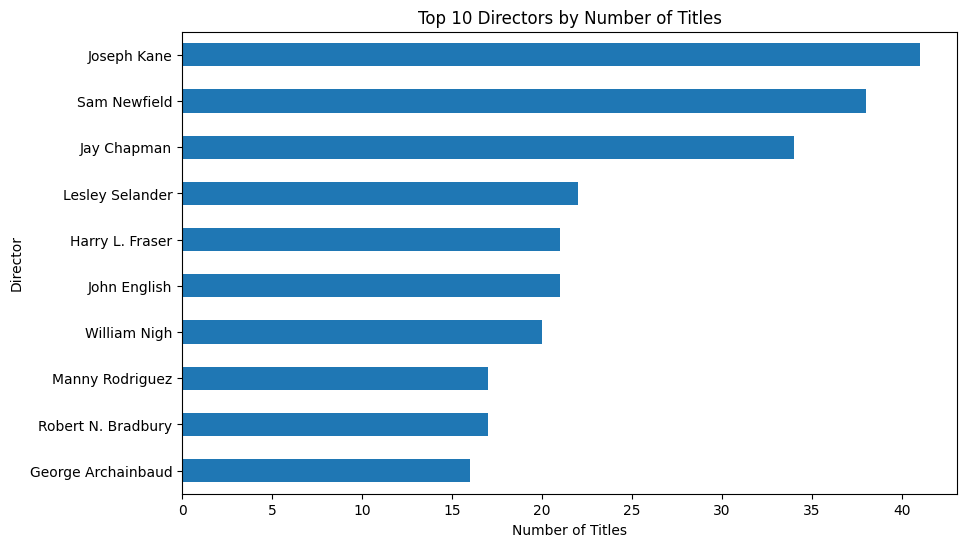

In [35]:
plt.figure(figsize=(10, 6))

top_directors.sort_values().plot(kind='barh')

plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

plt.show()

In [36]:
role_counts = df_clean['role'].value_counts()

role_counts

role
ACTOR       115793
DIRECTOR      8386
Name: count, dtype: int64

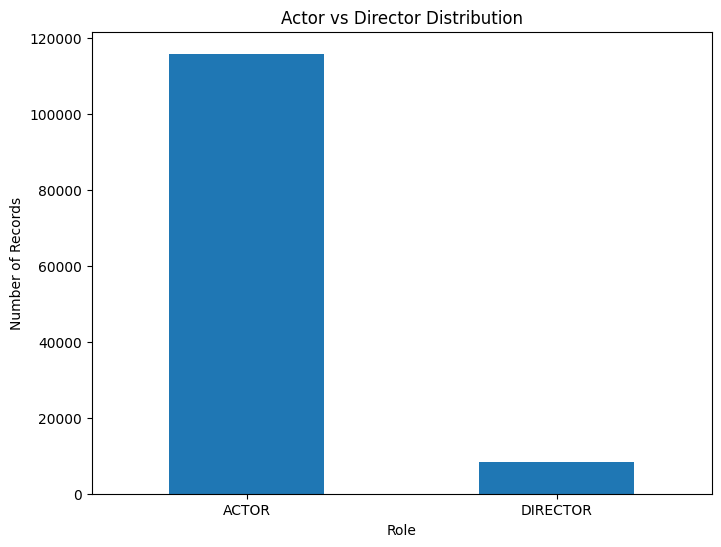

In [37]:
plt.figure(figsize=(8, 6))

role_counts.plot(kind='bar')

plt.title('Actor vs Director Distribution')
plt.xlabel('Role')
plt.ylabel('Number of Records')

plt.xticks(rotation=0)

plt.show()

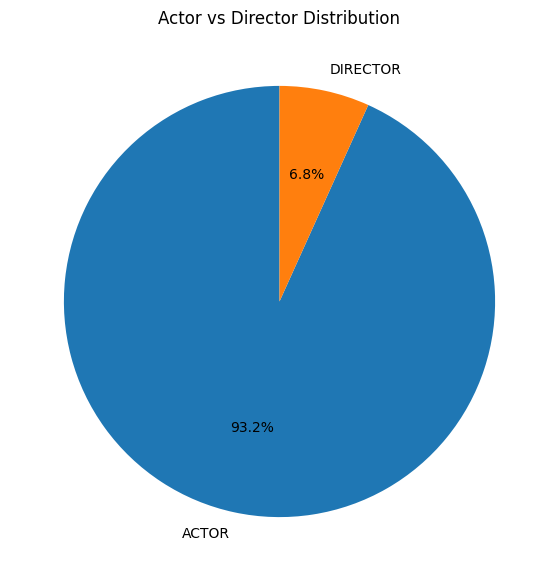

In [38]:
plt.figure(figsize=(7, 7))

role_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Actor vs Director Distribution')
plt.ylabel('')

plt.show()

In [39]:
title_counts = df_clean.groupby('id')['person_id'].nunique()

In [40]:
top_titles = title_counts.sort_values(ascending=False).head(10)

top_titles

id
tm458582    137
tm244162    135
tm33144     135
tm32643     133
tm67583     128
tm110555    124
tm312351    120
tm52046     117
tm192682    117
tm191110    117
Name: person_id, dtype: int64

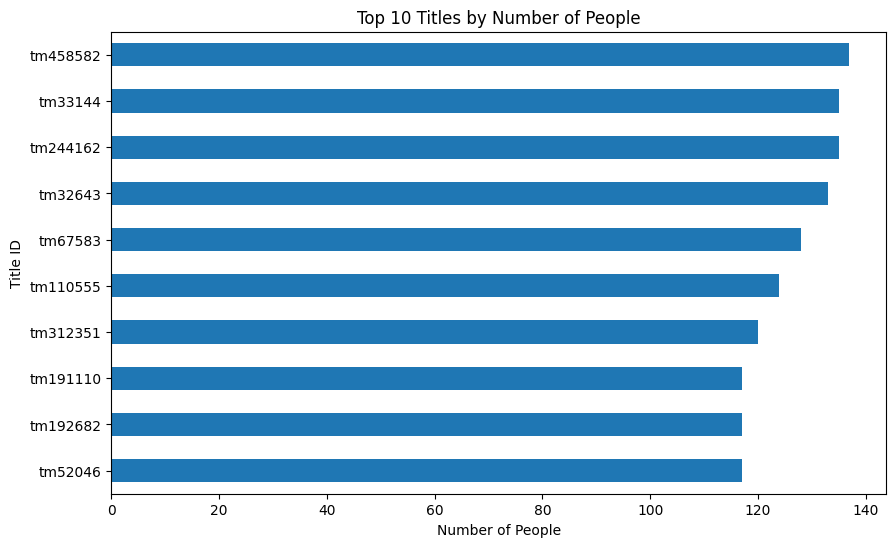

In [41]:
plt.figure(figsize=(10, 6))

top_titles.sort_values().plot(kind='barh')

plt.title('Top 10 Titles by Number of People')
plt.xlabel('Number of People')
plt.ylabel('Title ID')

plt.show()

In [42]:
top_characters = (
    df_clean[df_clean['character'] != 'Unknown']['character']
    .value_counts()
    .head(10)
)

top_characters

character
Himself                   1540
Self                      1245
Herself                    418
Henchman                   237
Dancer                     221
Doctor                     173
Self (archive footage)     146
Bartender                  142
Nurse                      132
Narrator                   127
Name: count, dtype: int64

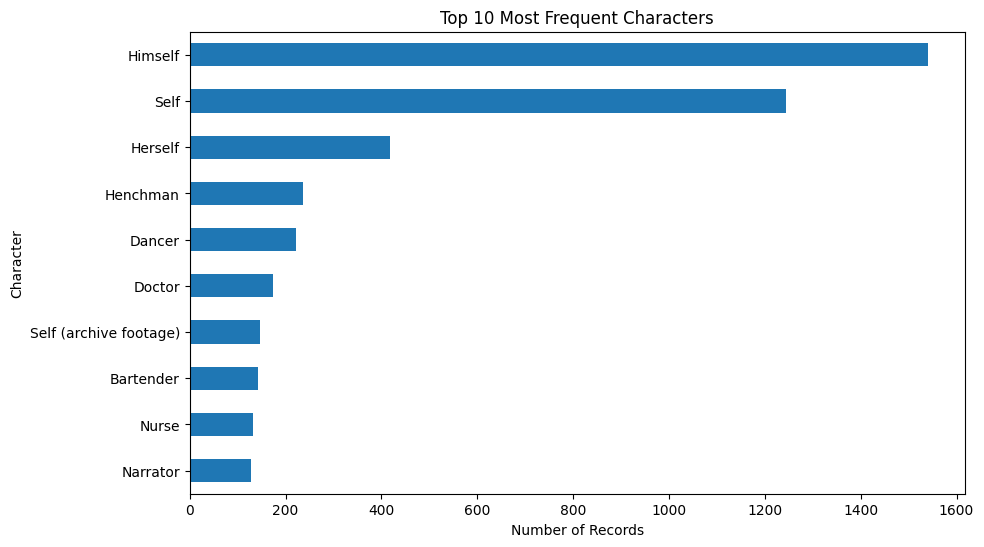

In [43]:
plt.figure(figsize=(10, 6))

top_characters.sort_values().plot(kind='barh')

plt.title('Top 10 Most Frequent Characters')
plt.xlabel('Number of Records')
plt.ylabel('Character')

plt.show()

In [44]:
title_counts = df_clean.groupby('id')['person_id'].nunique()

In [45]:
top_titles = title_counts.sort_values(ascending=False).head(10)

top_titles

id
tm458582    137
tm244162    135
tm33144     135
tm32643     133
tm67583     128
tm110555    124
tm312351    120
tm52046     117
tm192682    117
tm191110    117
Name: person_id, dtype: int64

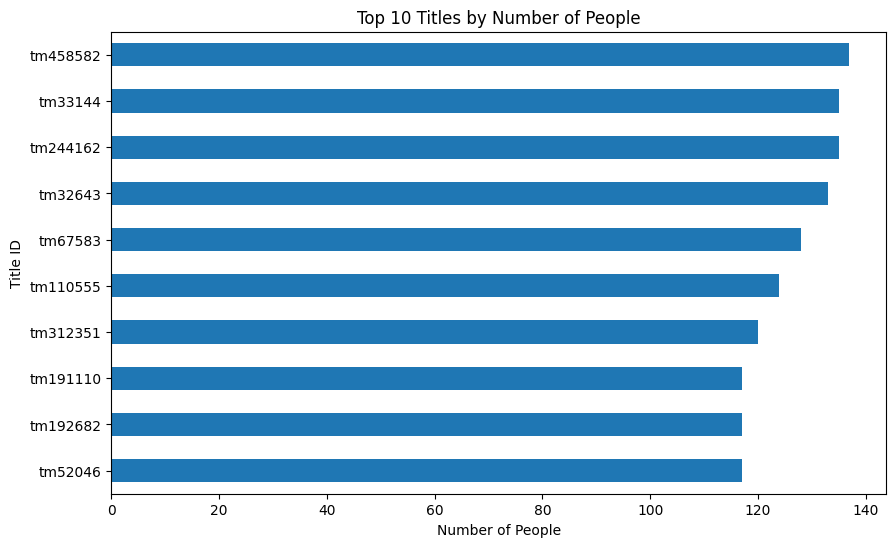

In [46]:
plt.figure(figsize=(10, 6))

top_titles.sort_values().plot(kind='barh')

plt.title('Top 10 Titles by Number of People')
plt.xlabel('Number of People')
plt.ylabel('Title ID')

plt.show()

In [47]:
top_characters = (
    df_clean[df_clean['character'] != 'Unknown']['character']
    .value_counts()
    .head(10)
)

top_characters

character
Himself                   1540
Self                      1245
Herself                    418
Henchman                   237
Dancer                     221
Doctor                     173
Self (archive footage)     146
Bartender                  142
Nurse                      132
Narrator                   127
Name: count, dtype: int64

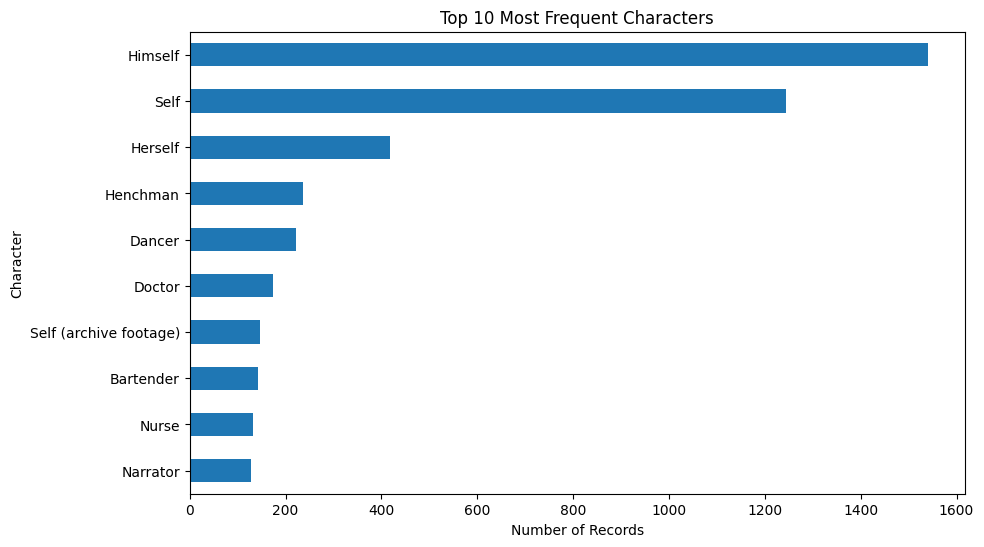

In [48]:
plt.figure(figsize=(10, 6))

top_characters.sort_values().plot(kind='barh')

plt.title('Top 10 Most Frequent Characters')
plt.xlabel('Number of Records')
plt.ylabel('Character')

plt.show()

In [49]:
actor_names = set(
    df_clean[df_clean['role'] == 'ACTOR']['name']
)

In [50]:
director_names = set(
    df_clean[df_clean['role'] == 'DIRECTOR']['name']
)

In [51]:
both_roles = actor_names.intersection(director_names)

len(both_roles)

1105

In [52]:
list(both_roles)[:20]

['David Avallone',
 'Charles B. Griffith',
 'Tim Alexander',
 'Jason Dbks Hampton',
 'Wayne Wang',
 'Doug Archibald',
 'Regina King',
 'Shinpei Hayashiya',
 'Mike Akel',
 'Bey Logan',
 'Eric Gorlow',
 'Wei Lo',
 'Dominic Burns',
 'Jenica Bergere',
 'Dave Wascavage',
 'Sally Field',
 'Charlie David',
 'Jason Mills',
 'Lucio Fulci',
 'Alfred E. Green']

In [53]:
total_people = df_clean['person_id'].nunique()

both_roles_percentage = (len(both_roles) / total_people) * 100

both_roles_percentage

1.372534406518607

In [54]:
top_actors_df = top_actors.reset_index()

top_actors_df.columns = ['Actor', 'Number_of_Titles']

top_actors_df

,Actor,Number_of_Titles
0,George 'Gabby' Hayes,49
1,Roy Rogers,45
2,Bess Flowers,44
3,Gene Autry,40
4,Nassar,37
5,Herman Hack,35
6,Earl Dwire,34
7,George Morrell,34
8,Forrest Taylor,34
9,Charles King,34


In [55]:
df_clean.to_csv("../data/movies_cleaned.csv", index=False)

In [56]:
role_percentage = df_clean['role'].value_counts(normalize=True) * 100

role_percentage

role
ACTOR       93.246845
DIRECTOR     6.753155
Name: proportion, dtype: float64

In [57]:
summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Unique People',
        'Unique Titles',
        'Actor Records',
        'Director Records',
        'People with Both Roles'
    ],
    'Value': [
        len(df_clean),
        df_clean['person_id'].nunique(),
        df_clean['id'].nunique(),
        (df_clean['role'] == 'ACTOR').sum(),
        (df_clean['role'] == 'DIRECTOR').sum(),
        len(both_roles)
    ]
})

summary

,Metric,Value
0,Total Records,124179
1,Unique People,80508
2,Unique Titles,8861
3,Actor Records,115793
4,Director Records,8386
5,People with Both Roles,1105


In [58]:
top_people = (
    df_clean.groupby('name')['id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_people

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Joseph Kane             41
Gene Autry              40
Sam Newfield            38
Nassar                  37
Herman Hack             35
George Morrell          34
Charles King            34
Name: id, dtype: int64

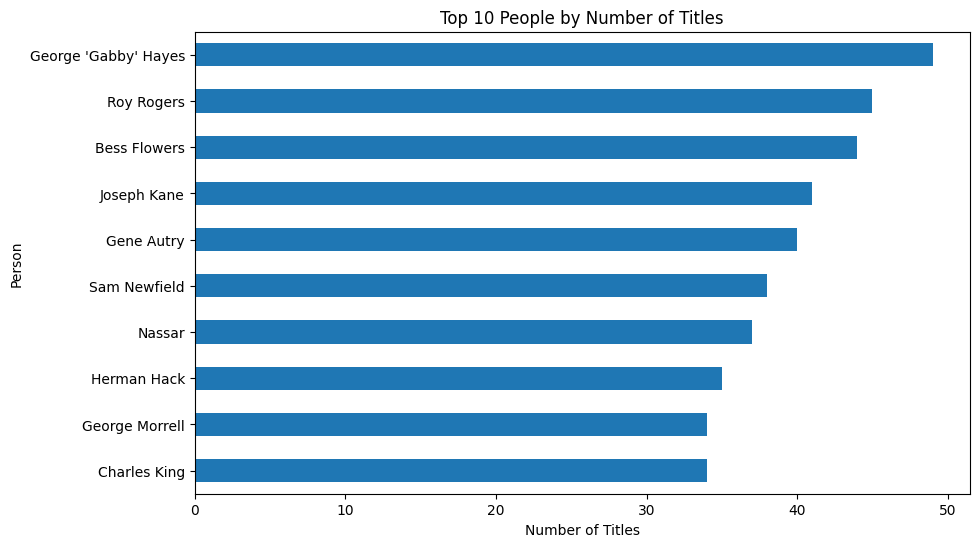

In [59]:
plt.figure(figsize=(10, 6))

top_people.sort_values().plot(kind='barh')

plt.title('Top 10 People by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Person')

plt.show()

In [60]:
person_title_counts = df_clean.groupby('name')['id'].nunique()

In [61]:
person_title_counts.describe()

count    79758.000000
mean         1.544597
std          1.604894
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         49.000000
Name: id, dtype: float64

In [62]:
one_title_people = (person_title_counts == 1).sum()

one_title_people

np.int64(60649)

In [63]:
ten_plus_people = (person_title_counts >= 10).sum()

ten_plus_people

np.int64(532)

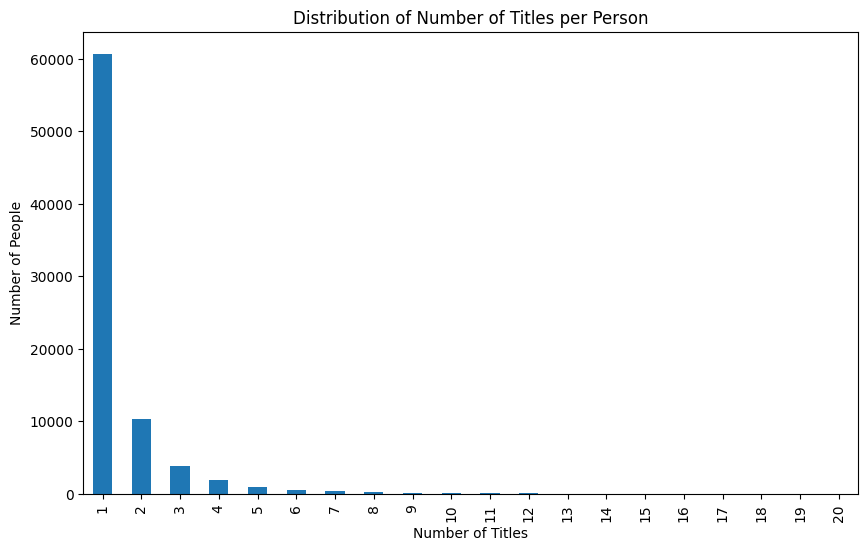

In [64]:
plt.figure(figsize=(10, 6))

person_title_counts.value_counts().sort_index().head(20).plot(kind='bar')

plt.title('Distribution of Number of Titles per Person')
plt.xlabel('Number of Titles')
plt.ylabel('Number of People')

plt.show()

In [65]:
actor_title_counts = (
    df_clean[df_clean['role'] == 'ACTOR']
    .groupby('name')['id']
    .nunique()
)

In [66]:
top_actors = actor_title_counts.sort_values(ascending=False).head(10)

top_actors

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Gene Autry              40
Nassar                  37
Herman Hack             35
Earl Dwire              34
George Morrell          34
Forrest Taylor          34
Charles King            34
Name: id, dtype: int64

In [67]:
actors_10_plus = (actor_title_counts >= 10).sum()

actors_10_plus

np.int64(500)

In [68]:
actor_title_counts.describe()

count    74572.000000
mean         1.550113
std          1.603943
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         49.000000
Name: id, dtype: float64

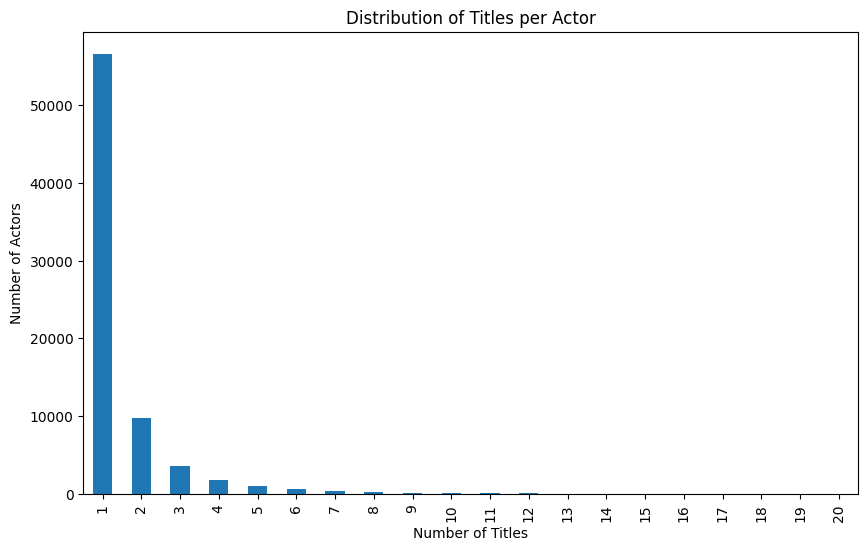

In [69]:
plt.figure(figsize=(10, 6))

actor_title_counts.value_counts().sort_index().head(20).plot(kind='bar')

plt.title('Distribution of Titles per Actor')
plt.xlabel('Number of Titles')
plt.ylabel('Number of Actors')

plt.show()

In [70]:
director_title_counts = (
    df_clean[df_clean['role'] == 'DIRECTOR']
    .groupby('name')['id']
    .nunique()
)

In [71]:
top_directors = director_title_counts.sort_values(ascending=False).head(10)

top_directors

name
Joseph Kane           41
Sam Newfield          38
Jay Chapman           34
Lesley Selander       22
John English          21
Harry L. Fraser       21
William Nigh          20
Robert N. Bradbury    17
Manny Rodriguez       17
George Archainbaud    16
Name: id, dtype: int64

In [72]:
directors_10_plus = (director_title_counts >= 10).sum()

directors_10_plus

np.int64(24)

In [73]:
director_title_counts.describe()

count    6291.000000
mean        1.332856
std         1.374478
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        41.000000
Name: id, dtype: float64

In [74]:
comparison = pd.DataFrame({
    'Role': ['Actor', 'Director'],
    'Average_Titles': [
        actor_title_counts.mean(),
        director_title_counts.mean()
    ],
    'Maximum_Titles': [
        actor_title_counts.max(),
        director_title_counts.max()
    ],
    'People_10_Plus_Titles': [
        (actor_title_counts >= 10).sum(),
        (director_title_counts >= 10).sum()
    ]
})

comparison

,Role,Average_Titles,Maximum_Titles,People_10_Plus_Titles
0,Actor,1.550113,49,500
1,Director,1.332856,41,24


In [33]:
plt.figure(figsize=(8, 6))

comparison.set_index('Role')['People_10_Plus_Titles'].plot(kind='bar')

plt.title('Actors vs Directors with 10+ Titles')
plt.xlabel('Role')
plt.ylabel('Number of People')
plt.xticks(rotation=0)

plt.savefig('../visualizations/actors_vs_directors_10plus.png', bbox_inches='tight')

plt.show()

NameError: name 'comparison' is not defined

<Figure size 800x600 with 0 Axes>

In [76]:
generic_characters = [
    'Himself',
    'Herself',
    'Self',
    'Self (archive footage)'
]

named_characters = df_clean[
    ~df_clean['character'].isin(generic_characters) &
    (df_clean['character'] != 'Unknown')
]

In [77]:
named_character_counts = (
    named_characters['character']
    .value_counts()
    .head(10)
)

named_character_counts

character
Henchman     237
Dancer       221
Doctor       173
Bartender    142
Nurse        132
Narrator     127
Sam          126
Reporter     114
Jack         107
Townsman     105
Name: count, dtype: int64

In [78]:
final_summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Unique People',
        'Unique Titles',
        'Actor Records',
        'Director Records',
        'People with Both Roles',
        'Average Titles per Actor',
        'Average Titles per Director',
        'Actors with 10+ Titles',
        'Directors with 10+ Titles'
    ],
    'Value': [
        len(df_clean),
        df_clean['person_id'].nunique(),
        df_clean['id'].nunique(),
        (df_clean['role'] == 'ACTOR').sum(),
        (df_clean['role'] == 'DIRECTOR').sum(),
        len(both_roles),
        round(actor_title_counts.mean(), 2),
        round(director_title_counts.mean(), 2),
        (actor_title_counts >= 10).sum(),
        (director_title_counts >= 10).sum()
    ]
})

final_summary

,Metric,Value
0,Total Records,124179.00
1,Unique People,80508.00
2,Unique Titles,8861.00
3,Actor Records,115793.00
4,Director Records,8386.00
5,People with Both Roles,1105.00
6,Average Titles per Actor,1.55
7,Average Titles per Director,1.33
8,Actors with 10+ Titles,500.00
9,Directors with 10+ Titles,24.00


In [79]:
role_percentage = (
    df_clean['role']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

role_percentage

role
ACTOR       93.25
DIRECTOR     6.75
Name: proportion, dtype: float64

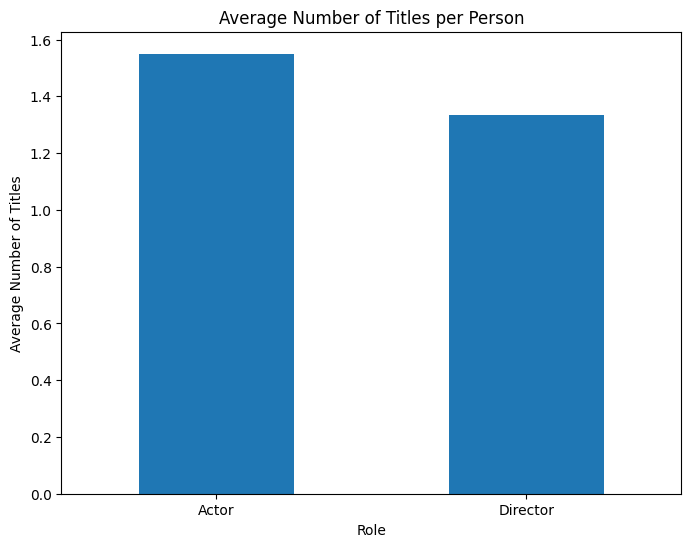

In [80]:
average_titles = pd.Series({
    'Actor': actor_title_counts.mean(),
    'Director': director_title_counts.mean()
})

plt.figure(figsize=(8, 6))

average_titles.plot(kind='bar')

plt.title('Average Number of Titles per Person')
plt.xlabel('Role')
plt.ylabel('Average Number of Titles')

plt.xticks(rotation=0)

plt.show()

In [81]:
role_percentage = (
    df_clean['role']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

role_percentage

role
ACTOR       93.25
DIRECTOR     6.75
Name: proportion, dtype: float64

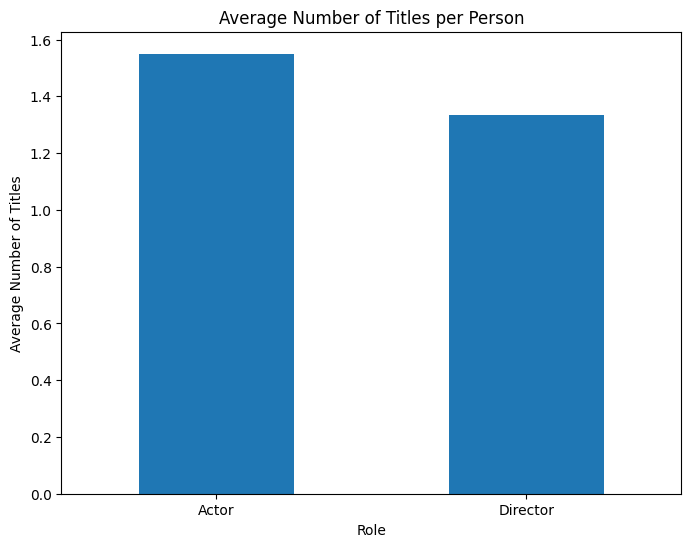

In [82]:
average_titles = pd.Series({
    'Actor': actor_title_counts.mean(),
    'Director': director_title_counts.mean()
})

plt.figure(figsize=(8, 6))

average_titles.plot(kind='bar')

plt.title('Average Number of Titles per Person')
plt.xlabel('Role')
plt.ylabel('Average Number of Titles')

plt.xticks(rotation=0)

plt.show()

In [11]:
actor_title_counts = (
    df_clean[df_clean['role'] == 'ACTOR']
    .groupby('name')['id']
    .nunique()
)

top_actors = actor_title_counts.sort_values(ascending=False).head(10)

top_actors

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Gene Autry              40
Nassar                  37
Herman Hack             35
Earl Dwire              34
George Morrell          34
Forrest Taylor          34
Charles King            34
Name: id, dtype: int64

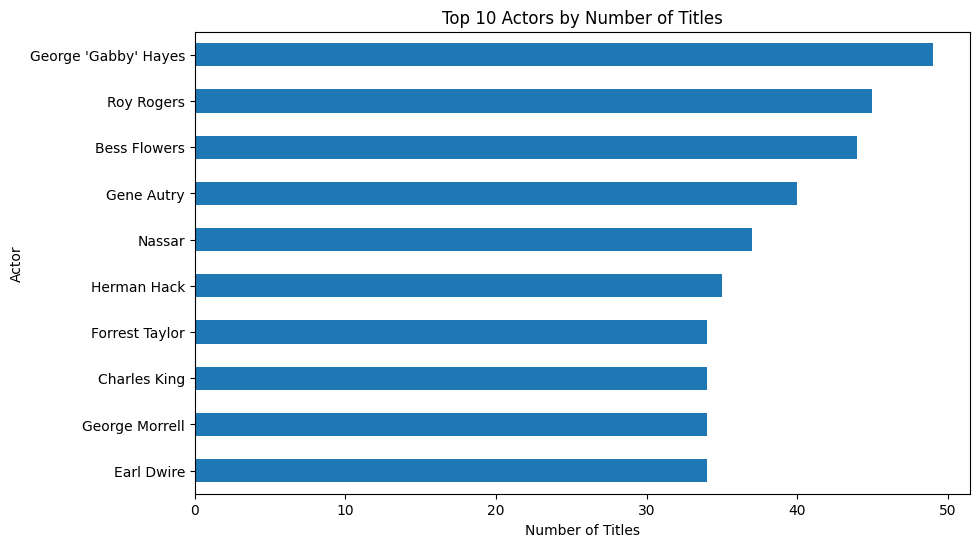

In [12]:
plt.figure(figsize=(10, 6))

top_actors.sort_values().plot(kind='barh')

plt.title('Top 10 Actors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')

plt.savefig('../visualizations/top_10_actors.png', bbox_inches='tight')

plt.show()

In [15]:
director_title_counts = (
    df_clean[df_clean['role'] == 'DIRECTOR']
    .groupby('name')['id']
    .nunique()
)

top_directors = director_title_counts.sort_values(ascending=False).head(10)

top_directors

name
Joseph Kane           41
Sam Newfield          38
Jay Chapman           34
Lesley Selander       22
John English          21
Harry L. Fraser       21
William Nigh          20
Robert N. Bradbury    17
Manny Rodriguez       17
George Archainbaud    16
Name: id, dtype: int64

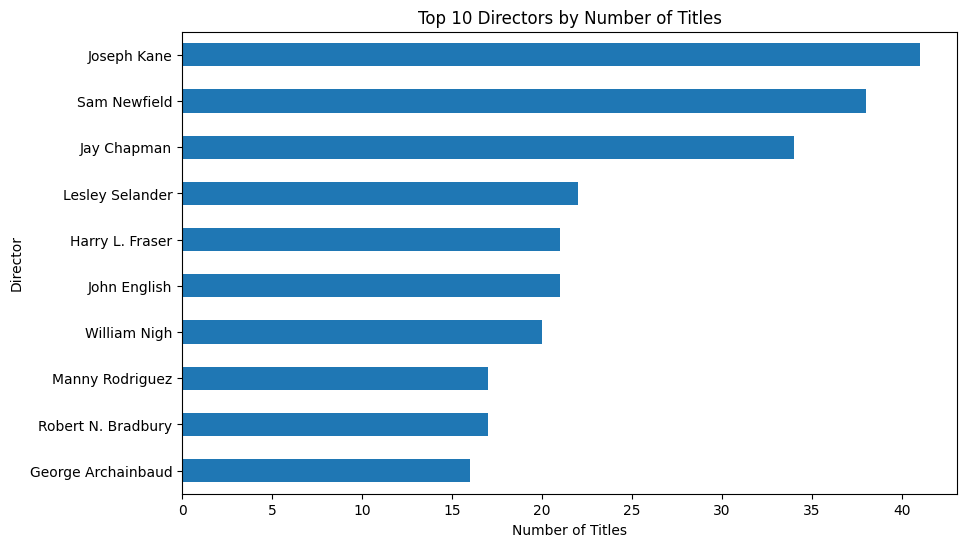

In [16]:
plt.figure(figsize=(10, 6))

top_directors.sort_values().plot(kind='barh')

plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

plt.savefig('../visualizations/top_10_directors.png', bbox_inches='tight')

plt.show()

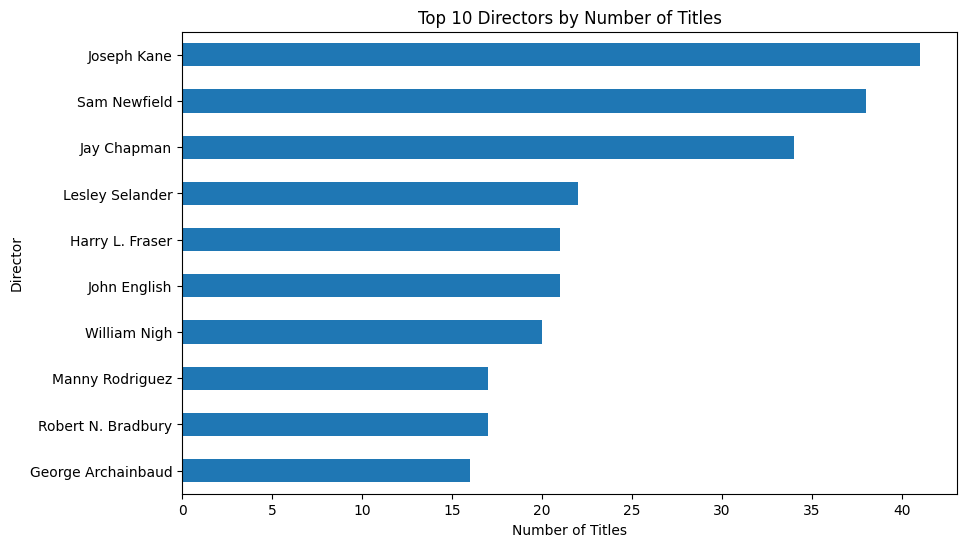

In [17]:
plt.figure(figsize=(10, 6))

top_directors.sort_values().plot(kind='barh')

plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

plt.savefig('../visualizations/top_10_directors.png', bbox_inches='tight')

plt.show()

In [19]:
generic_characters = [
    'Himself',
    'Herself',
    'Self',
    'Self (archive footage)'
]

named_characters = df_clean[
    ~df_clean['character'].isin(generic_characters) &
    (df_clean['character'] != 'Unknown')
]

named_character_counts = (
    named_characters['character']
    .value_counts()
    .head(10)
)

named_character_counts

character
Henchman     237
Dancer       221
Doctor       173
Bartender    142
Nurse        132
Narrator     127
Sam          126
Reporter     114
Jack         107
Townsman     105
Name: count, dtype: int64

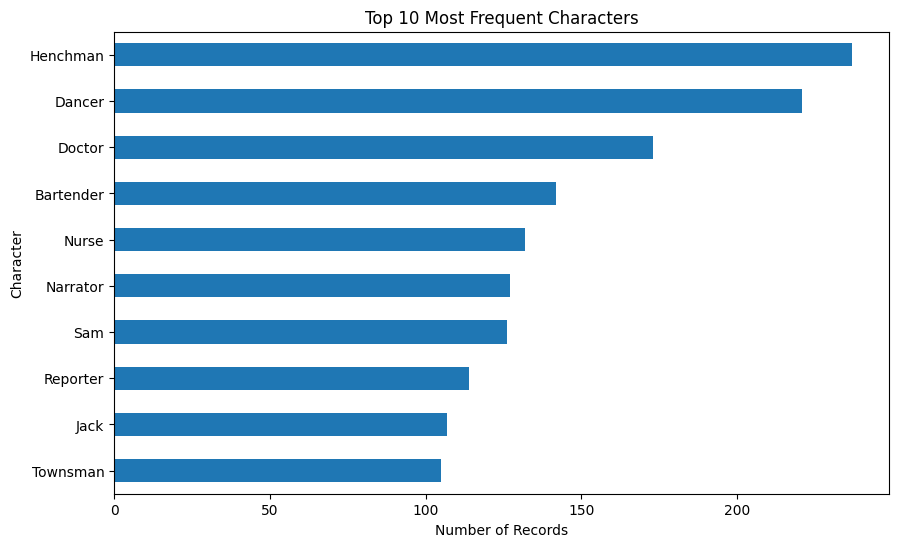

In [20]:
plt.figure(figsize=(10, 6))

named_character_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Most Frequent Characters')
plt.xlabel('Number of Records')
plt.ylabel('Character')

plt.savefig('../visualizations/top_10_characters.png', bbox_inches='tight')

plt.show()

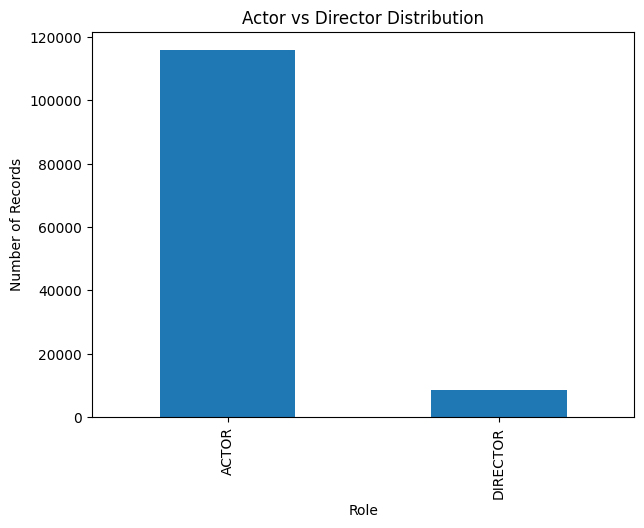

In [21]:
plt.figure(figsize=(7, 5))

role_counts = df_clean['role'].value_counts()

role_counts.plot(kind='bar')

plt.title('Actor vs Director Distribution')
plt.xlabel('Role')
plt.ylabel('Number of Records')

plt.savefig('../visualizations/actor_vs_director.png', bbox_inches='tight')

plt.show()

In [22]:
both_roles = (
    df_clean.groupby('person_id')['role']
    .nunique()
)

both_roles_count = both_roles[both_roles == 2].count()

both_roles_count

np.int64(996)

In [23]:
role_counts_per_person = (
    df_clean.groupby(['person_id', 'role'])
    .size()
    .unstack(fill_value=0)
)

people_both_roles = role_counts_per_person[
    (role_counts_per_person['ACTOR'] > 0) &
    (role_counts_per_person['DIRECTOR'] > 0)
]

len(people_both_roles)

996

In [24]:
top_actors

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Gene Autry              40
Nassar                  37
Herman Hack             35
Earl Dwire              34
George Morrell          34
Forrest Taylor          34
Charles King            34
Name: id, dtype: int64

In [25]:
top_directors

name
Joseph Kane           41
Sam Newfield          38
Jay Chapman           34
Lesley Selander       22
John English          21
Harry L. Fraser       21
William Nigh          20
Robert N. Bradbury    17
Manny Rodriguez       17
George Archainbaud    16
Name: id, dtype: int64

In [26]:
role_activity = pd.DataFrame({
    'Role': ['Actor', 'Director'],
    'Average Titles': [
        round(actor_title_counts.mean(), 2),
        round(director_title_counts.mean(), 2)
    ],
    'Maximum Titles': [
        actor_title_counts.max(),
        director_title_counts.max()
    ],
    'People with 10+ Titles': [
        (actor_title_counts >= 10).sum(),
        (director_title_counts >= 10).sum()
    ]
})

role_activity

,Role,Average Titles,Maximum Titles,People with 10+ Titles
0,Actor,1.55,49,500
1,Director,1.33,41,24


In [27]:
total_people = df_clean['person_id'].nunique()

both_roles_percentage = round(
    (len(people_both_roles) / total_people) * 100,
    2
)

both_roles_percentage

1.24

In [28]:
top_people = (
    df_clean.groupby('name')['id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_people

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Joseph Kane             41
Gene Autry              40
Sam Newfield            38
Nassar                  37
Charles King            35
Herman Hack             35
Forrest Taylor          34
Name: id, dtype: int64

In [29]:
character_analysis = (
    named_characters['character']
    .value_counts()
    .head(10)
)

character_analysis

character
Henchman     237
Dancer       221
Doctor       173
Bartender    142
Nurse        132
Narrator     127
Sam          126
Reporter     114
Jack         107
Townsman     105
Name: count, dtype: int64

In [30]:

both_role_people = (
    df_clean.groupby('name')['role']
    .apply(lambda x: set(x))
)

both_role_people = both_role_people[
    both_role_people.apply(
        lambda x: {'ACTOR', 'DIRECTOR'}.issubset(x)
    )
]

both_role_people.head(20)

name
A. Venkatesh            {ACTOR, DIRECTOR}
A.R. Murugadoss         {ACTOR, DIRECTOR}
Aaron Woodley           {ACTOR, DIRECTOR}
Abel Berry              {ACTOR, DIRECTOR}
Abish Mathew            {ACTOR, DIRECTOR}
Adam Christian Clark    {ACTOR, DIRECTOR}
Adam Gascho             {ACTOR, DIRECTOR}
Adam Gierasch           {ACTOR, DIRECTOR}
Adam Goldberg           {ACTOR, DIRECTOR}
Adam Green              {ACTOR, DIRECTOR}
Adam Mervis             {ACTOR, DIRECTOR}
Adam Nee                {ACTOR, DIRECTOR}
Ajai Vasudev            {ACTOR, DIRECTOR}
Ajay Devgn              {ACTOR, DIRECTOR}
Ajay Koundinya          {ACTOR, DIRECTOR}
Akarsh Khurana          {ACTOR, DIRECTOR}
Akiva Schaffer          {ACTOR, DIRECTOR}
Al Carretta             {ACTOR, DIRECTOR}
Alain Chabat            {ACTOR, DIRECTOR}
Alan Hale               {ACTOR, DIRECTOR}
Name: role, dtype: object

In [31]:
both_role_count = len(both_role_people)

both_role_count

1105

In [32]:
project_summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Unique People',
        'Unique Titles',
        'Actor Records',
        'Director Records',
        'Actor Percentage',
        'Director Percentage',
        'People with Both Roles',
        'Most Active Actor',
        'Most Active Director',
        'Most Frequent Character'
    ],
    'Value': [
        len(df_clean),
        df_clean['person_id'].nunique(),
        df_clean['id'].nunique(),
        (df_clean['role'] == 'ACTOR').sum(),
        (df_clean['role'] == 'DIRECTOR').sum(),
        '93.25%',
        '6.75%',
        both_role_count,
        top_actors.index[0],
        top_directors.index[0],
        character_analysis.index[0]
    ]
})

project_summary

,Metric,Value
0,Total Records,124179
1,Unique People,80508
2,Unique Titles,8861
3,Actor Records,115793
4,Director Records,8386
5,Actor Percentage,93.25%
6,Director Percentage,6.75%
7,People with Both Roles,1105
8,Most Active Actor,George 'Gabby' Hayes
9,Most Active Director,Joseph Kane


In [34]:
comparison = pd.DataFrame({
    'Role': ['Actor', 'Director'],
    'People_10_Plus_Titles': [
        (actor_title_counts >= 10).sum(),
        (director_title_counts >= 10).sum()
    ]
})

comparison

,Role,People_10_Plus_Titles
0,Actor,500
1,Director,24


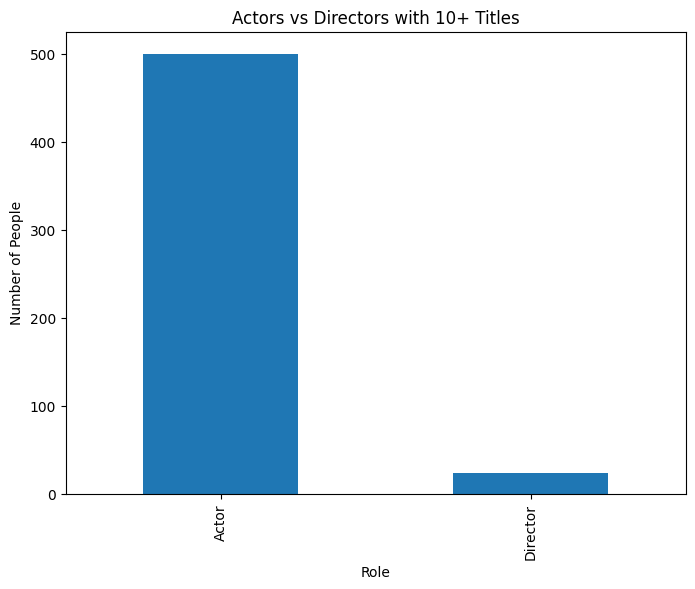

In [35]:
plt.figure(figsize=(8, 6))

comparison.set_index('Role')['People_10_Plus_Titles'].plot(kind='bar')

plt.title('Actors vs Directors with 10+ Titles')
plt.xlabel('Role')
plt.ylabel('Number of People')

plt.savefig('../visualizations/actors_vs_directors_10plus.png',
            bbox_inches='tight')

plt.show()